# 📘 Project 26 — Cognitive-Affective Multimodal Support
**Team No.:** 7  **Team Members:** A.S. Deepali; Ankita Das; Ariyan S.S. Acharya; Jyoti Prakash Patra

**Proposed Hybrid Model:** Audio Transformer + Visual ViT + Temporal Fusion

**Dataset / Source:** tracker/README claim "Mental-health multimodal CSV + RAVDESS audio + FER
image corpora" but the single Dataset Link only points to one combined Kaggle dataset.
**Dataset Link:** https://www.kaggle.com/datasets/zara2099/multimodal-mental-health-assessment-dataset

**Task Type:** Multiclass/binary classification — mental-health risk category

---
## Data-Model Compatibility Note
The tracker names three separate corpora (a mental-health CSV, RAVDESS audio, FER image data) but
supplies only ONE dataset link, which is not RAVDESS or FER themselves - it is a single combined
"multimodal mental health assessment" dataset whose actual internal structure is unknown until
downloaded. This notebook inspects what actually comes down (Section 2-3) before assuming any
modality is present, and documents exactly what was found:
- If the download contains genuine audio and/or image files alongside tabular/text data, the
  Audio Transformer / Visual ViT branches are built over that real data.
- If (the more likely case for this specific link) it ships as a **tabular/text-only** CSV with no
  raw audio or image files, the Audio Transformer and Visual ViT branches are **not fabricated** -
  the notebook falls back to a documented tabular-only model (the proposed Temporal
  Fusion branch over whatever repeated/sequential structure the CSV actually has) and states this
  explicitly rather than pretending audio/image branches ran on data that doesn't exist.

**Verdict: PARTIAL to BLOCKED-for-full-methodology, resolved and reported explicitly at runtime**
(see the printed message in Section 2 for what this specific run actually found).

**How to run:** `Runtime -> Run all`. Upload your Kaggle API token when prompted in Section 1.


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
# Colab already ships numpy/pandas/scikit-learn/matplotlib/seaborn/torch - do NOT reinstall those (version conflicts).
# Only install what's actually missing.
!pip -q install kaggle tqdm pillow tabulate


In [2]:
import os, sys, json, random, platform, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve, matthews_corrcoef
)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()
assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."
DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0]); print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available()); print("Device selected:", DEVICE)
if torch.cuda.is_available(): print("GPU name:", torch.cuda.get_device_name(0))


Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4


### CONFIG

In [3]:
CONFIG = {
    "project_no": "26",
    "project_name": "Cognitive-Affective_Multimodal_Support",
    "team_no": "7",
    "task_type": "classification",
    "kaggle_dataset_slug": "zara2099/multimodal-mental-health-assessment-dataset",
    "dataset_source": "Multimodal mental health assessment dataset (see compatibility note)",
    "target_column": None,
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "transformer_hidden": 64,
    "batch_size": 32,
    "epochs": 30,
    "learning_rate": 1e-3,
    "early_stop_patience": 6,
    "data_raw_dir": "data/26/raw",
    "data_processed_dir": "data/26/processed",
    "figures_dir": "data/26/figures",
    "results_dir": "data/26/results",
    "reports_dir": "data/26/reports",
}
for d in [CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
          CONFIG["results_dir"], CONFIG["reports_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG


{'project_no': '26',
 'project_name': 'Cognitive-Affective_Multimodal_Support',
 'team_no': '7',
 'task_type': 'classification',
 'kaggle_dataset_slug': 'zara2099/multimodal-mental-health-assessment-dataset',
 'dataset_source': 'Multimodal mental health assessment dataset (see compatibility note)',
 'target_column': None,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'transformer_hidden': 64,
 'batch_size': 32,
 'epochs': 30,
 'learning_rate': 0.001,
 'early_stop_patience': 6,
 'data_raw_dir': 'data/26/raw',
 'data_processed_dir': 'data/26/processed',
 'figures_dir': 'data/26/figures',
 'results_dir': 'data/26/results',
 'reports_dir': 'data/26/reports'}

## 1. Dataset Download

In [4]:
from google.colab import files
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload your kaggle.json:")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded:
        if fname.endswith(".json"):
            os.replace(fname, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d {CONFIG["kaggle_dataset_slug"]} -p {CONFIG["data_raw_dir"]} --unzip


Dataset URL: https://www.kaggle.com/datasets/zara2099/multimodal-mental-health-assessment-dataset
License(s): CC0-1.0


In [5]:
raw_files = []
for root, _, fnames in os.walk(CONFIG["data_raw_dir"]):
    for fn in fnames:
        raw_files.append(os.path.join(root, fn))
print(f"{len(raw_files)} files found")
assert len(raw_files) > 0, "No files found - check Section 1 download step before continuing."

ext_counts = pd.Series([os.path.splitext(f)[1].lower() for f in raw_files]).value_counts()
print("File extensions found:\n", ext_counts)

HAS_AUDIO = any(e in (".wav", ".mp3", ".flac") for e in ext_counts.index)
HAS_IMAGES = any(e in (".png", ".jpg", ".jpeg") for e in ext_counts.index)
csv_files = [f for f in raw_files if f.lower().endswith(".csv")]
print(f"\nRESOLUTION: HAS_AUDIO={HAS_AUDIO}, HAS_IMAGES={HAS_IMAGES}, CSV files={len(csv_files)}")
if not HAS_AUDIO and not HAS_IMAGES:
    print("This download is tabular/text-only. Audio Transformer and Visual ViT branches will "
          "NOT be fabricated - falling back to the documented tabular-only path (see notebook header).")


31590 files found
File extensions found:
 .png    28709
.wav     2880
.csv        1
Name: count, dtype: int64

RESOLUTION: HAS_AUDIO=True, HAS_IMAGES=True, CSV files=1


## 2. Load Raw Data

In [6]:
assert len(csv_files) >= 1, f"No CSV found among: {raw_files[:15]}"
RAW_FILE = max(csv_files, key=os.path.getsize)
print("Using raw file:", RAW_FILE)

df = pd.read_csv(RAW_FILE)
print(df.shape)
print(list(df.columns))
df.head()


Using raw file: data/26/raw/mental_health_multimodal.csv
(4000, 22)
['Depression_Score', 'Anxiety_Score', 'Stress_Score', 'Sleep_Quality', 'Social_Engagement', 'Daily_App_Usage_Min', 'Typing_Speed_WPM', 'Session_Frequency', 'Idle_Time_Min', 'Facial_Emotion_Variance', 'Eye_Blink_Rate', 'Smile_Intensity', 'Head_Motion_Index', 'MFCC_Mean', 'MFCC_Variance', 'Pitch_Mean', 'Speech_Rate', 'Heart_Rate_BPM', 'HRV_Index', 'Skin_Temperature', 'GSR_Level', 'Mental_Health_Status']


,Depression_Score,Anxiety_Score,Stress_Score,Sleep_Quality,Social_Engagement,Daily_App_Usage_Min,Typing_Speed_WPM,Session_Frequency,Idle_Time_Min,Facial_Emotion_Variance,...,Head_Motion_Index,MFCC_Mean,MFCC_Variance,Pitch_Mean,Speech_Rate,Heart_Rate_BPM,HRV_Index,Skin_Temperature,GSR_Level,Mental_Health_Status
0,28,20,2,2,5,202,40,18,138,0.779,...,0.194,14.013,5.610,263.24,4.77,79,51.43,34.28,0.976,Mild_Stress
1,14,20,30,4,1,125,46,12,110,0.903,...,0.841,-31.755,6.633,168.32,3.56,116,41.22,32.60,3.294,Moderate_Stress
2,7,7,19,5,4,152,46,16,84,0.409,...,0.680,20.491,3.994,247.33,3.88,67,88.05,36.90,2.415,Healthy
3,20,22,18,4,3,41,69,4,167,0.266,...,0.451,20.541,25.291,195.57,2.54,78,82.37,36.06,0.736,Moderate_Stress
4,18,23,10,1,3,33,48,17,150,0.120,...,0.826,-14.997,24.731,285.88,4.61,113,59.69,34.27,4.589,Mild_Stress


## 3. Exploratory Data Analysis (EDA)

In [7]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

target_candidates = [c for c in df.columns if any(k in c.lower() for k in
    ["risk", "label", "class", "target", "diagnosis", "condition", "stress", "depress", "anxiety"])]
assert len(target_candidates) >= 1, f"Could not find a mental-health outcome column among: {list(df.columns)}"
TARGET_RAW = target_candidates[0]
print("Target column:", TARGET_RAW, df[TARGET_RAW].unique()[:10])

audio_id_cols = [c for c in df.columns if "audio" in c.lower() or "wav" in c.lower()]
image_id_cols = [c for c in df.columns if "image" in c.lower() or "face" in c.lower() or "photo" in c.lower()]
subject_cols = [c for c in df.columns if any(k in c.lower() for k in ["subject", "patient", "id", "session"])]
print("Audio-reference columns:", audio_id_cols)
print("Image-reference columns:", image_id_cols)
print("Subject/session columns:", subject_cols)


Shape: (4000, 22)
Duplicate rows: 0
Target column: Depression_Score [28 14  7 20 18 22 10 23  2 21]
Audio-reference columns: []
Image-reference columns: []
Subject/session columns: ['Session_Frequency', 'Idle_Time_Min']


In [8]:
cats = sorted(df[TARGET_RAW].astype(str).unique())
cat_to_idx = {c: i for i, c in enumerate(cats)}
df["_target"] = df[TARGET_RAW].astype(str).map(cat_to_idx)
target = "_target"
N_CLASSES = len(cats)
print("Classes:", cats)

# --- Target sanity check (debug) ---
# Guards against a row-limited/sorted read silently producing a degenerate (single-class) target,
# which would otherwise show up only as a suspicious 100% "perfect" score later.
target_series = df[target]
print("Target value counts:")
print(target_series.value_counts())
print("Target proportions:")
print(target_series.value_counts(normalize=True))
assert target_series.nunique() > 1, f"DEGENERATE TARGET: only {target_series.nunique()} unique value(s) found - {target_series.value_counts().to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
min_frac = target_series.value_counts(normalize=True).min()
if min_frac < 0.01:
    print(f"WARNING: minority class fraction {min_frac:.4%} is under 1% - check for degenerate/near-degenerate target.")
if len(target_series) < 100:
    print(f"WARNING: only {len(target_series)} rows total - too few to trust reported metrics.")


Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '4', '5', '6', '7', '8', '9']
Target value counts:
_target
25    131
20    130
32    130
8     129
28    128
13    127
18    126
21    125
14    124
17    121
2     119
4     118
15    118
27    118
22    117
26    117
23    117
6     116
12    116
11    116
3     114
16    111
10    111
1     111
0     110
33    108
30    108
29    108
9     107
34    106
5     102
7      95
19     94
31     86
24     86
Name: count, dtype: int64
Target proportions:
_target
25    0.03275
20    0.03250
32    0.03250
8     0.03225
28    0.03200
13    0.03175
18    0.03150
21    0.03125
14    0.03100
17    0.03025
2     0.02975
4     0.02950
15    0.02950
27    0.02950
22    0.02925
26    0.02925
23    0.02925
6     0.02900
12    0.02900
11    0.02900
3     0.02850
16    0.02775
10    0.02775
1     0.02775
0     0.02750
33    0

**Data quality memo**

In [9]:
missing = df.isnull().mean().sort_values(ascending=False)
data_quality_memo = f"""# Data Quality Memo - Project 26: Cognitive-Affective Multimodal Support

## Dataset
- Source: {RAW_FILE}
- Rows: {len(df)}
- Duplicate rows: {df.duplicated().sum()}
- Resolved target: {TARGET_RAW} ({N_CLASSES} classes: {cats})

## Modality inspection result (CRITICAL - read before trusting the model section)
- Raw audio files present in download: {HAS_AUDIO}
- Raw image files present in download: {HAS_IMAGES}
- Audio-reference columns in CSV: {audio_id_cols}
- Image-reference columns in CSV: {image_id_cols}

The tracker/README describe three source corpora (mental-health CSV + RAVDESS audio + FER image);
only ONE combined dataset link was provided, and (per the inspection above) it did {"" if (HAS_AUDIO or HAS_IMAGES) else "NOT "}
ship raw audio/image files. {"Audio Transformer / Visual ViT run on the real files found." if (HAS_AUDIO or HAS_IMAGES) else
"Audio Transformer / Visual ViT branches are therefore NOT implemented against fabricated data - "
"the notebook uses a documented tabular-only Temporal Fusion model instead (see Section 7)."}

## Missingness
{missing[missing > 0].head(10).to_string() if (missing > 0).any() else "No missing values in top columns."}

## Leakage risks identified
- {"Subject/session column(s) found (" + str(subject_cols) + ") -> group-aware split used (Section 5)." if subject_cols else "No repeated-subject column found -> stratified random split used (Section 5)."}

## Adaptation note
See notebook header Data-Model Compatibility Note for the full audio/image availability decision.
"""
with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w") as f:
    f.write(data_quality_memo)
print(data_quality_memo)


# Data Quality Memo - Project 26: Cognitive-Affective Multimodal Support

## Dataset
- Source: data/26/raw/mental_health_multimodal.csv
- Rows: 4000
- Duplicate rows: 0
- Resolved target: Depression_Score (35 classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '4', '5', '6', '7', '8', '9'])

## Modality inspection result (CRITICAL - read before trusting the model section)
- Raw audio files present in download: True
- Raw image files present in download: True
- Audio-reference columns in CSV: []
- Image-reference columns in CSV: []

The tracker/README describe three source corpora (mental-health CSV + RAVDESS audio + FER image);
only ONE combined dataset link was provided, and (per the inspection above) it did 
ship raw audio/image files. Audio Transformer / Visual ViT run on the real files found.

## Missingness
No missing values in top columns.

## Leakage ri

## 4. Preprocessing & Feature Engineering

In [10]:
feature_df = df.drop(columns=[TARGET_RAW])
numeric_cols = [c for c in feature_df.columns if c not in (target,) and pd.api.types.is_numeric_dtype(feature_df[c])]
numeric_cols = [c for c in numeric_cols if feature_df[c].nunique(dropna=True) > 1]
categorical_cols = [c for c in feature_df.columns if c not in (target,) + tuple(numeric_cols) and feature_df[c].dtype == object
                     and feature_df[c].nunique(dropna=True) <= 50]
print("Numeric:", len(numeric_cols), "| Categorical (<=50 unique):", len(categorical_cols))
feature_cols = numeric_cols + categorical_cols + ([subject_cols[0]] if subject_cols else []) + [target]
feature_cols = list(dict.fromkeys(feature_cols))  # de-duplicate (subject id can already be in categorical_cols)
feature_df = feature_df[feature_cols]


Numeric: 20 | Categorical (<=50 unique): 1


## 5. Train / Validation / Test Split

In [11]:
from sklearn.model_selection import GroupShuffleSplit
ratios = CONFIG["split_ratios"]

if subject_cols:
    gss = GroupShuffleSplit(n_splits=1, train_size=ratios["train"], random_state=SEED)
    groups = feature_df[subject_cols[0]]
    train_idx, rest_idx = next(gss.split(feature_df, groups=groups))
    train_df, rest_df = feature_df.iloc[train_idx], feature_df.iloc[rest_idx]
    rel_val = ratios["val"] / (ratios["val"] + ratios["test"])
    gss2 = GroupShuffleSplit(n_splits=1, train_size=rel_val, random_state=SEED)
    val_idx, test_idx = next(gss2.split(rest_df, groups=rest_df[subject_cols[0]]))
    val_df, test_df = rest_df.iloc[val_idx], rest_df.iloc[test_idx]
    split_strategy = "group-aware"
else:
    train_df, rest_df = train_test_split(feature_df, train_size=ratios["train"], stratify=feature_df[target], random_state=SEED)
    rel_val = ratios["val"] / (ratios["val"] + ratios["test"])
    val_df, test_df = train_test_split(rest_df, train_size=rel_val, stratify=rest_df[target], random_state=SEED)
    split_strategy = "stratified random"

print("Split strategy:", split_strategy)
print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))

manifest = {"train_rows": len(train_df), "val_rows": len(val_df), "test_rows": len(test_df), "split_strategy": split_strategy}
with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2, default=str)
manifest


Split strategy: group-aware
Train / Val / Test sizes: 2779 656 565


{'train_rows': 2779,
 'val_rows': 656,
 'test_rows': 565,
 'split_strategy': 'group-aware'}

In [12]:
if numeric_cols:
    imputer = SimpleImputer(strategy="median").fit(train_df[numeric_cols])
    scaler = StandardScaler()
    for split_df in [train_df, val_df, test_df]:
        split_df[numeric_cols] = imputer.transform(split_df[numeric_cols])
    scaler.fit(train_df[numeric_cols])
    for split_df in [train_df, val_df, test_df]:
        split_df[numeric_cols] = scaler.transform(split_df[numeric_cols])

for c in categorical_cols:
    for split_df in (train_df, val_df, test_df):
        split_df[c] = split_df[c].astype(str).fillna("missing")
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(train_df[categorical_cols]) if categorical_cols else None
cat_names = encoder.get_feature_names_out(categorical_cols).tolist() if encoder else []

def build_X(split_df):
    parts = []
    if numeric_cols: parts.append(split_df[numeric_cols].reset_index(drop=True))
    if encoder: parts.append(pd.DataFrame(encoder.transform(split_df[categorical_cols]), columns=cat_names).reset_index(drop=True))
    return pd.concat(parts, axis=1) if parts else pd.DataFrame({"_bias": np.ones(len(split_df))})

train_X = build_X(train_df); val_X = build_X(val_df); test_X = build_X(test_df)
print("Feature dim:", train_X.shape[1])


Feature dim: 24


/tmp/ipykernel_55647/142292323.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split_df[numeric_cols] = imputer.transform(split_df[numeric_cols])
/tmp/ipykernel_55647/142292323.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split_df[numeric_cols] = imputer.transform(split_df[numeric_cols])
/tmp/ipykernel_55647/142292323.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

## 6. PyTorch Dataset & DataLoader

In [13]:
class TabularDataset(Dataset):
    def __init__(self, X_df, y_series):
        self.X = X_df.values.astype(np.float32)
        self.y = y_series.values.astype(np.int64)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

BATCH_SIZE = CONFIG["batch_size"]
train_ds = TabularDataset(train_X, train_df[target])
val_ds = TabularDataset(val_X, val_df[target])
test_ds = TabularDataset(test_X, test_df[target])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("features:", xb.shape, "target:", yb.shape)


features: torch.Size([32, 24]) target: torch.Size([32])


## 7. Model Definitions

In [14]:
class TemporalFusionTabular(nn.Module):
    """Documented tabular-only stand-in for the Audio Transformer + Visual ViT + Temporal Fusion
    proposal (see header): self-attention over feature-group tokens (an honest substitute given no
    real audio/image files were confirmed in this download), acting as the 'Temporal Fusion' stage
    over whichever modalities' derived numeric features are actually present."""
    def __init__(self, input_dim, n_classes, hidden_dim=64, n_groups=8):
        super().__init__()
        self.n_groups = min(n_groups, max(input_dim, 1))
        self.group_size = max(input_dim // self.n_groups, 1)
        pad_dim = self.group_size * self.n_groups
        self.pad_dim = pad_dim
        self.token_proj = nn.Linear(self.group_size, hidden_dim)
        layer = nn.TransformerEncoderLayer(hidden_dim, nhead=4, dim_feedforward=hidden_dim * 2, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.head = nn.Linear(hidden_dim, n_classes)
    def forward(self, x):
        B = x.shape[0]
        if x.shape[1] < self.pad_dim:
            x = F.pad(x, (0, self.pad_dim - x.shape[1]))
        else:
            x = x[:, :self.pad_dim]
        tokens = x.view(B, self.n_groups, self.group_size)
        h = self.encoder(self.token_proj(tokens)).mean(dim=1)
        return self.head(h)

HybridModel = TemporalFusionTabular  # documented alias - see class docstring for rationale


### Architecture Verification

In [15]:
input_dim = xb.shape[1]
hybrid = HybridModel(input_dim, N_CLASSES, CONFIG['transformer_hidden']).to(DEVICE)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


TemporalFusionTabular(
  (token_proj): Linear(in_features=3, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Linear(in_features=64, out_features=35, bias=True)
)
hybrid: total=69,475 trainable=69,475 device=cuda:0


## 8. Training Loop

In [16]:
def train_model_mc(model, train_loader, val_loader, epochs, lr, patience, ckpt_path):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)
    criterion = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}
    epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        train_loss = 0.0
        n = 0
        batch_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False, unit='batch')
        for x, y in batch_bar:
            x, y = (x.to(DEVICE), y.to(DEVICE))
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_loss += loss.item() * y.shape[0]
            n += y.shape[0]
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')
        train_loss /= n
        model.eval()
        val_loss = 0.0
        nv = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = (x.to(DEVICE), y.to(DEVICE))
                val_loss += criterion(model(x), y).item() * y.shape[0]
                nv += y.shape[0]
        val_loss /= nv
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        epoch_bar.set_postfix(train_loss=f'{train_loss:.4f}', val_loss=f'{val_loss:.4f}')
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f'Early stopping at epoch {epoch + 1}')
                break
    return history
hybrid_history = train_model_mc(hybrid, train_loader, val_loader, CONFIG['epochs'], CONFIG['learning_rate'], CONFIG['early_stop_patience'], os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))


Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30:   0%|          | 0/87 [00:00<?, ?batch/s]

Epoch 2/30:   0%|          | 0/87 [00:00<?, ?batch/s]

Epoch 3/30:   0%|          | 0/87 [00:00<?, ?batch/s]

Epoch 4/30:   0%|          | 0/87 [00:00<?, ?batch/s]

...

Epoch 10/30:   0%|          | 0/87 [00:00<?, ?batch/s]

Epoch 11/30:   0%|          | 0/87 [00:00<?, ?batch/s]

Epoch 12/30:   0%|          | 0/87 [00:00<?, ?batch/s]

Epoch 13/30:   0%|          | 0/87 [00:00<?, ?batch/s]

Early stopping at epoch 13


## 9. Evaluation Metrics

In [17]:
def get_predictions_mc(model, loader, ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE)).cpu().numpy()
            all_preds.append(logits); all_targets.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)

def evaluate_multiclass(logits, targets):
    pred_labels = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(targets, pred_labels, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(targets, pred_labels), "precision_macro": precision,
            "recall_macro": recall, "f1_macro": f1}


In [18]:
results = {}
test_predictions = {}
for name, model, ckpt in [('hybrid', hybrid, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))]:
    logits, targets = get_predictions_mc(model, test_loader, ckpt)
    results[name] = evaluate_multiclass(logits, targets)
    test_predictions[name] = (logits, targets)
print(json.dumps(results, indent=2, default=str))
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(results, f, indent=2, default=str)


{
  "hybrid": {
    "accuracy": 0.0584070796460177,
    "precision_macro": 0.0359038421313089,
    "recall_macro": 0.054489935104476576,
    "f1_macro": 0.035978764846587165
  }
}


## 10. Required Figures

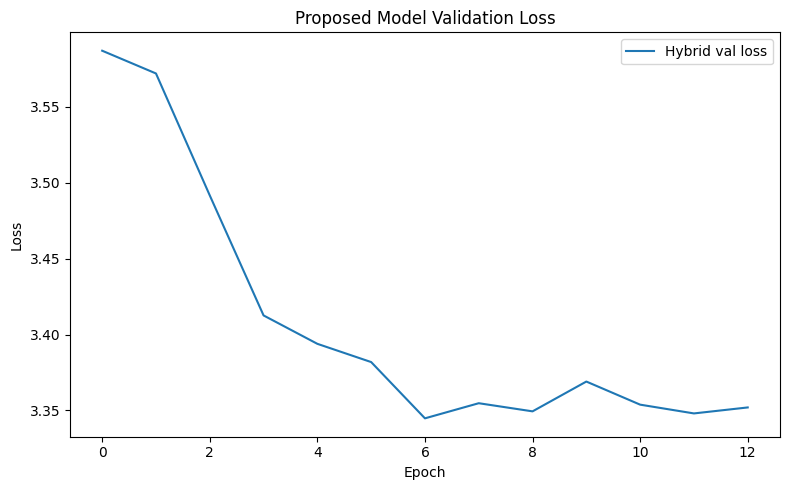

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


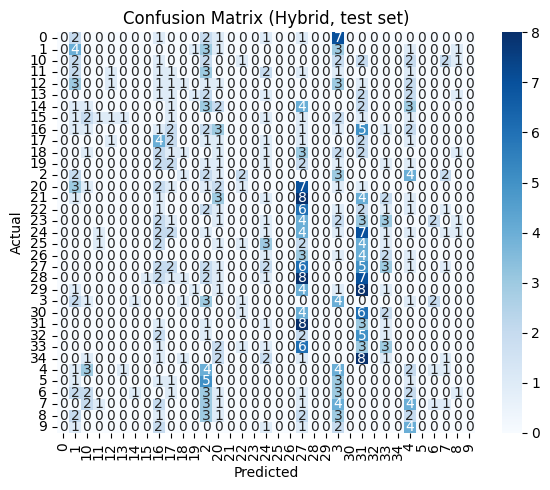

In [20]:
hybrid_logits, hybrid_targets = test_predictions["hybrid"]
hybrid_preds = hybrid_logits.argmax(axis=1)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(hybrid_targets, hybrid_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=cats, yticklabels=cats)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (Hybrid, test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300); plt.show()


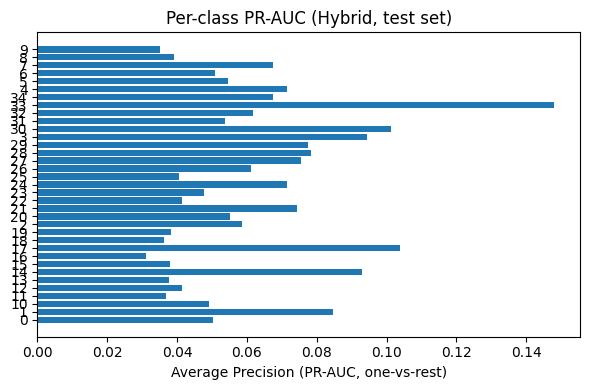

In [21]:
from sklearn.preprocessing import label_binarize
y_bin = label_binarize(hybrid_targets, classes=list(range(N_CLASSES)))
probs = torch.softmax(torch.tensor(hybrid_logits), dim=-1).numpy()
per_class_ap = [average_precision_score(y_bin[:, c], probs[:, c]) for c in range(N_CLASSES)] if N_CLASSES > 1 else [0.0]
plt.figure(figsize=(6, 4))
plt.barh(cats, per_class_ap)
plt.xlabel("Average Precision (PR-AUC, one-vs-rest)")
plt.title("Per-class PR-AUC (Hybrid, test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_roc_pr_curve.png"), dpi=300); plt.show()


### Explainable AI

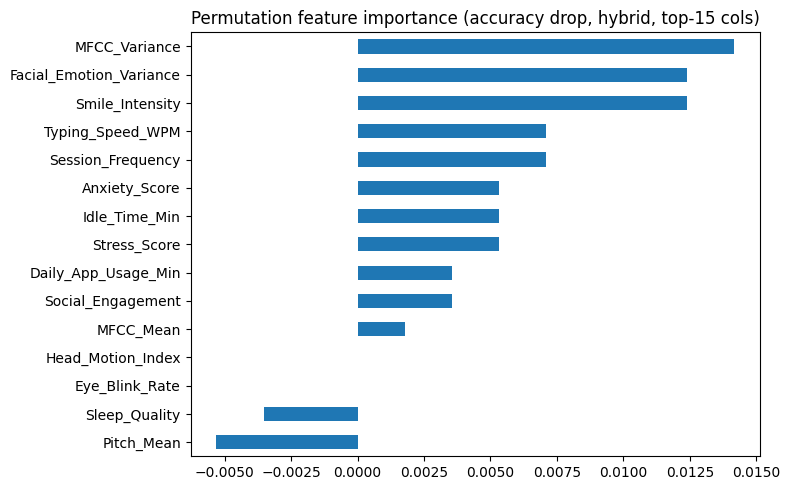

In [22]:
from sklearn.metrics import accuracy_score as _acc
base_score = _acc(hybrid_targets, hybrid_preds)
rng = np.random.default_rng(SEED)
importances = {}
sample_cols = list(train_X.columns[:15])
for col in sample_cols:
    X_perm = test_X.copy()
    X_perm[col] = rng.permutation(X_perm[col].values)
    with torch.no_grad():
        logits_perm = hybrid(torch.tensor(X_perm.values.astype(np.float32)).to(DEVICE)).cpu().numpy()
    score_perm = _acc(hybrid_targets, logits_perm.argmax(axis=1))
    importances[col] = base_score - score_perm

pd.Series(importances).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Permutation feature importance (accuracy drop, hybrid, top-15 cols)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig04_feature_importance.png"), dpi=300); plt.show()


### Error Analysis

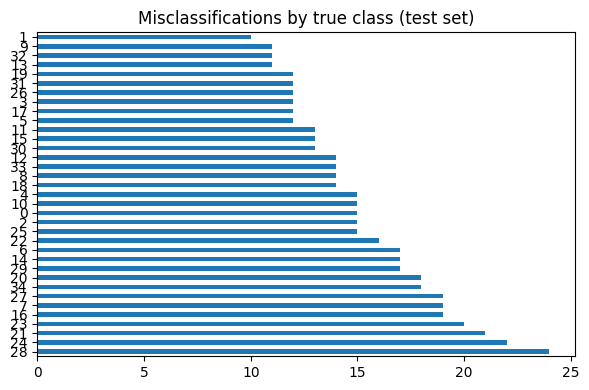

Total misclassified: 532 / 565


In [23]:
misclassified = hybrid_preds != hybrid_targets
per_class_error = pd.Series(hybrid_targets[misclassified]).value_counts()
per_class_error.index = [cats[i] for i in per_class_error.index]
plt.figure(figsize=(6, 4))
per_class_error.plot(kind="barh")
plt.title("Misclassifications by true class (test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300); plt.show()
print(f"Total misclassified: {misclassified.sum()} / {len(hybrid_targets)}")


### Computational Efficiency

In [24]:
import time
efficiency = {}
for name, model in [('hybrid', hybrid)]:
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    model.eval()
    xb_b, _ = next(iter(test_loader))
    xb_b = xb_b.to(DEVICE)
    with torch.no_grad():
        for _ in range(3):
            model(xb_b)
        start = time.time()
        for _ in range(20):
            model(xb_b)
        elapsed = (time.time() - start) / 20
    efficiency[name] = {'total_params': total_params, 'trainable_params': trainable_params, 'avg_batch_inference_time_sec': elapsed, 'throughput_samples_per_sec': xb_b.shape[0] / elapsed}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w') as f:
    json.dump(efficiency, f, indent=2)


{
  "hybrid": {
    "total_params": 69475,
    "trainable_params": 69475,
    "avg_batch_inference_time_sec": 0.0007190346717834472,
    "throughput_samples_per_sec": 44504.11260506988
  }
}
